In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Palette categorica fissa: ogni massa mantiene sempre lo stesso colore,
# in tutti i grafici del notebook (il colore codifica l'identita').
COLORI_MASSE = {
    "m_jj":   "tab:blue",
    "m_jjj":  "tab:orange",
    "m_lv":   "tab:green",
    "m_jlv":  "tab:red",
    "m_bb":   "tab:purple",
    "m_wbb":  "tab:brown",
    "m_wwbb": "tab:pink",
}
ETICHETTE_MASSE = {
    "m_jj":   r"$m_{jj}$",
    "m_jjj":  r"$m_{jjj}$",
    "m_lv":   r"$m_{\ell\nu}$",
    "m_jlv":  r"$m_{j\ell\nu}$",
    "m_bb":   r"$m_{bb}$",
    "m_wbb":  r"$m_{Wbb}$",
    "m_wwbb": r"$m_{WWbb}$",
}

# Probing lineare

In [3]:
with open("../results/riproduzione/probing_deep_low_seme0.json") as f:
    p2014 = json.load(f)
with open("../results/moderno/probing_deep_low_seme0.json") as f:
    pmod = json.load(f)

In [4]:
masse = pmod["masse"]
r2 = pmod["r2"]   # dizionario: "input", "casuale_stratoK", "stratoK"

In [5]:
def matrice(p, prefisso="strato"):
    n = p["n_strati"]
    return np.array([p["r2"][f"{prefisso}{k}"] for k in range(1, n+1)])

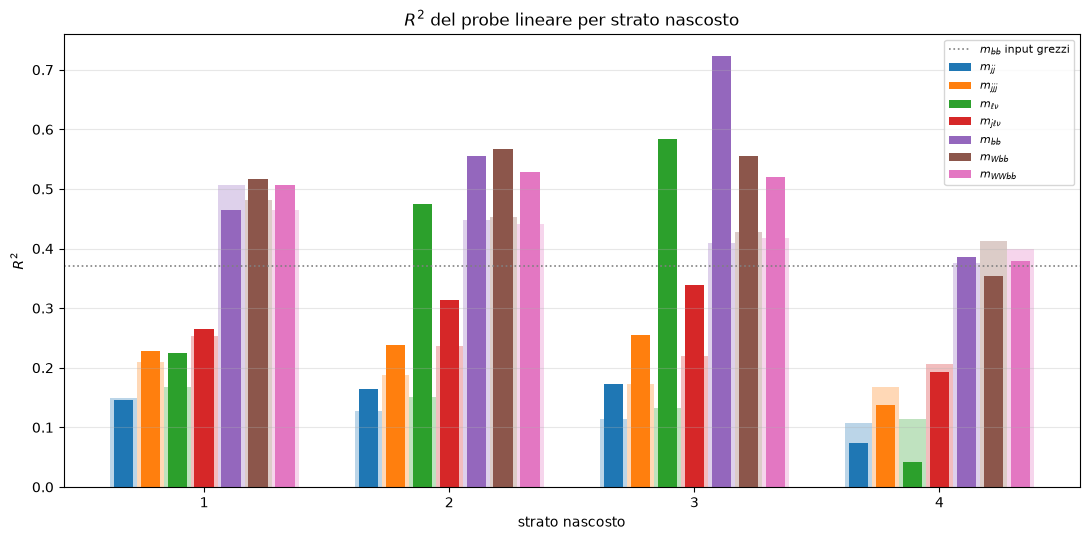

In [29]:
M = matrice(pmod)                    # (4, 7)
C = matrice(pmod, "casuale_strato")
inp = np.array(pmod["r2"]["input"])
strati = np.arange(1, 5)

fig, ax = plt.subplots(figsize=(11, 5.5))

larghezza = 0.11
offset = (np.arange(len(masse)) - (len(masse) - 1) / 2) * larghezza

for j, nome in enumerate(masse):
    colore = COLORI_MASSE[nome]
    posizioni = strati + offset[j]
    ax.bar(posizioni, C[:, j], larghezza, color=colore, alpha=0.3)
    ax.bar(posizioni, M[:, j], larghezza * 0.72, color=colore,
           label=ETICHETTE_MASSE[nome])

ax.axhline(y=inp[4], color="gray", linestyle=":", linewidth=1.2,
           label="$m_{bb}$ input grezzi")

ax.set_title("$R^2$ del probe lineare per strato nascosto")
ax.set_xlabel("strato nascosto")
ax.set_ylabel("$R^2$")
ax.set_xticks(strati)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### $R^2$ del probe lineare in funzione della profondità

Ogni linea continua è una massa invariante; la tratteggiata dello stesso
colore è il riferimento ottenuto con una rete della stessa forma ma **non
addestrata**. Il confronto va fatto verticalmente, fra continua e
tratteggiata allo stesso strato: la differenza è ciò che l'addestramento
ha aggiunto, al netto della semplice proiezione in 300 dimensioni.

Si leggono tre cose.

**Le tratteggiate calano in modo monotono.** Una rete casuale non aggiunge
informazione: ogni strato ne perde un po', perché la ReLU azzera metà dei
valori. È il degrado di riferimento.

**Le continue salgono fino al terzo strato.** La rete costruisce
progressivamente quantità da cui le masse sono linearmente leggibili,
partendo da variabili grezze in cui non lo erano. Su $m_{bb}$ si passa da
$R^2 = 0.37$ sugli input a $0.72$ allo strato 3; su $m_{\ell\nu}$ da
$0.13$ a $0.58$. È la verifica diretta dell'affermazione del paper, che
era invece dedotta indirettamente dalle prestazioni.

**Al quarto strato tutte crollano**, in alcuni casi sotto il livello della
rete casuale. Lo strato immediatamente precedente all'uscita è ottimizzato
per comprimere l'evento in un singolo numero, la decisione segnale/fondo:
ciò che non serve a quella decisione viene scartato. Non è degrado
passivo — è eliminazione attiva, e infatti $m_{\ell\nu}$, che ha potere
discriminante nullo, è quella che viene scartata di più.

La rete quindi **costruisce** le masse nei primi strati e le **consuma**
nell'ultimo.

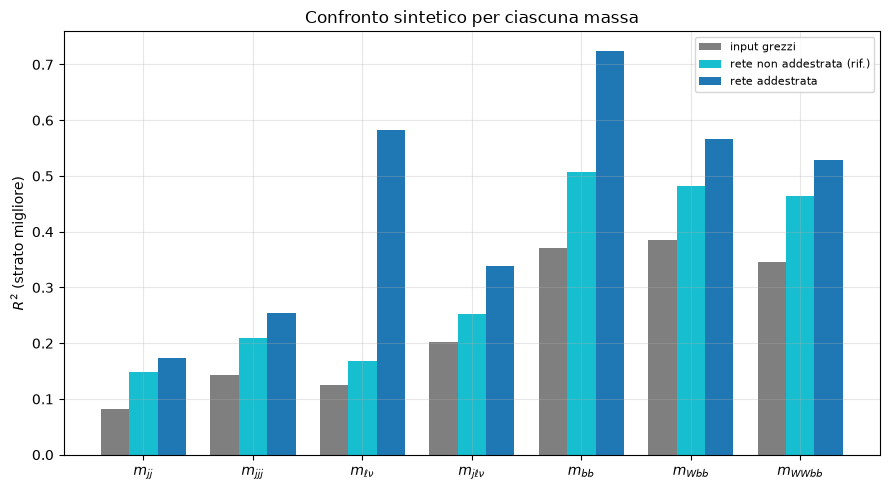

In [ ]:
x = np.arange(len(masse))
w = 0.26
migliore = M.max(axis=0)          # strato migliore per ciascuna massa
migliore_c = C.max(axis=0)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - w, inp, w, label="input grezzi", color="tab:gray")
ax.bar(x, migliore_c, w, label="rete non addestrata (rif.)", color="tab:cyan")
ax.bar(x + w, migliore, w, label="rete addestrata", color="tab:blue")

ax.set_title("Confronto sintetico per ciascuna massa")
ax.set_ylabel("$R^2$ (strato migliore)")
ax.set_xticks(x)
ax.set_xticklabels([ETICHETTE_MASSE[m] for m in masse])
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [8]:
import numpy as np, torch, sys
sys.path.insert(0, "../src")
from sklearn.linear_model import Ridge
from data import prepara_dati
from models import MLP

STACK, CART = "moderno", "moderno"
N_TR, N_VA, N_TE = 10_000_000, 500_000, 500_000
NP_FIT, NP_TEST = 200_000, 50_000

dx = prepara_dati(feature_set="low",  n_train=N_TR, n_val=N_VA, n_test=N_TE, silenzioso=True)
dy = prepara_dati(feature_set="high", n_train=N_TR, n_val=N_VA, n_test=N_TE, silenzioso=True)
X = np.ascontiguousarray(dx["val"][0][:NP_FIT+NP_TEST])
Y = np.ascontiguousarray(dy["val"][0][:NP_FIT+NP_TEST])

rete = MLP(n_input=21, n_strati=4, n_unita=300, attivazione="relu")
rete.load_state_dict(torch.load(f"../results/{CART}/deep_low_seme0_modello.pt", map_location="cpu"))
rete.eval()

with torch.no_grad():
    _, att = rete(torch.from_numpy(X), restituisci_attivazioni=True)
att = [a.numpy() for a in att]

def probe(R):
    m = Ridge(alpha=10).fit(R[:NP_FIT], Y[:NP_FIT])
    return m.predict(R[NP_FIT:])

pred_input = probe(X)
pred_L1    = probe(att[0])      # strato 1
pred_L3    = probe(att[2])      # strato 3, il migliore
Y_test = Y[NP_FIT:]

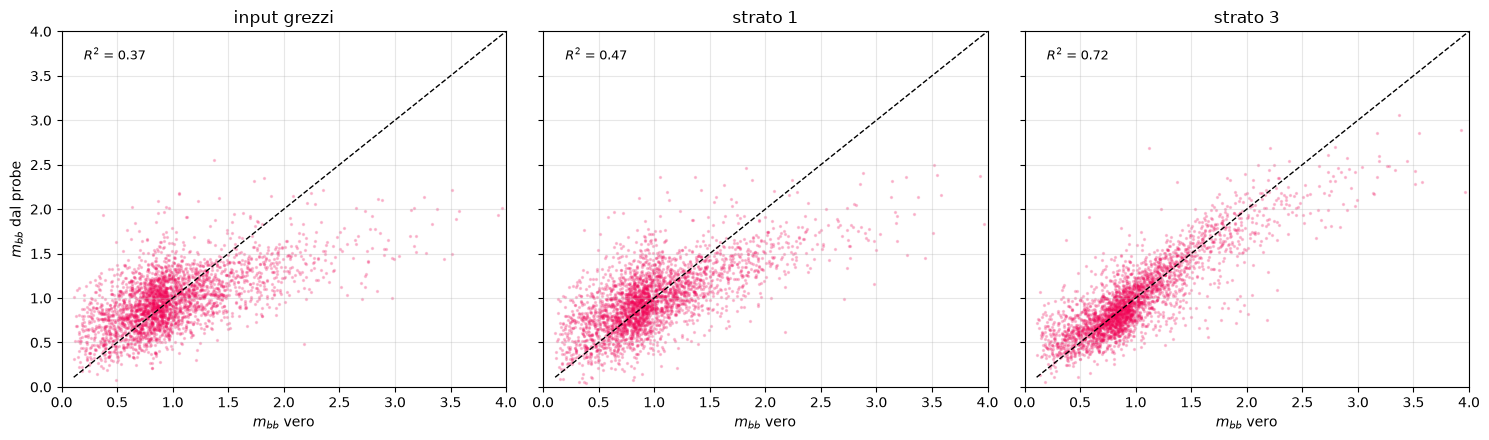

In [ ]:
from sklearn.metrics import r2_score

i = np.random.choice(len(Y_test), 3000, replace=False)
j = 4   # m_bb
fig, ax = plt.subplots(1, 3, figsize=(15,4.5), sharex=True, sharey=True)
for a, p, t in zip(ax, [pred_input, pred_L1, pred_L3], ["input grezzi", "strato 1", "strato 3"]):
    a.scatter(Y_test[i,j], p[i,j], s=2, alpha=0.2, color="#f00457")
    lim = [Y_test[i,j].min(), Y_test[i,j].max()]
    a.plot(lim, lim, "k--", lw=1)
    r2_val = r2_score(Y_test[:,j], p[:,j])
    a.text(0.05, 0.92, f"$R^2$ = {r2_val:.2f}", transform=a.transAxes, fontsize=9)
    a.set_title(t); a.set_xlabel("$m_{bb}$ vero")
    a.grid(alpha=0.3)

ax[0].set_xlim(0, 4)
ax[0].set_ylim(0, 4)
ax[0].set_ylabel("$m_{bb}$ dal probe")
fig.tight_layout()
plt.show()